In [1]:
!pip install langchain_community langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/119.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.0 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-protocol
    Found existing installation: langchain-protocol 0.0.16
    Uninstalling langchain-protocol-0.0.16:
      Successfully uninstalled langchain-protocol-0.0.16
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.3
    Uninstalling langchain-core-1.4.3:
      Successfully uninstalled langchain-core-1.4.3
ERROR: pip's dependency resolver does not currently take 

In [2]:
from typing import Annotated
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
# from dotenv import load_dotenv
from google.colab import userdata
from IPython.display import Image, display
import gradio as gr
from langgraph.prebuilt import ToolNode, tools_condition
import requests
import os
from langchain_openai import ChatOpenAI
from typing import TypedDict

## LangSmith Setup

Adding LangSmith to observe what happens internally when the graph executes.

To see each node execution, tool invocation, and message flow inside the LangSmith dashboard so debugging becomes easier.

In [3]:
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"

os.environ["LANGSMITH_API_KEY"] = userdata.get('LANGSMITH_API_KEY')
os.environ["LANGSMITH_PROJECT"] = userdata.get('LANGSMITH_PROJECT')

## Search Tool

Using Google Serper as an external search utility so the agent can fetch up-to-date information whenever its own knowledge is insufficient.

In [4]:
from langchain_community.utilities import GoogleSerperAPIWrapper

SERPER_API_KEY = userdata.get('SERPER_API_KEY')
serper = GoogleSerperAPIWrapper(serper_api_key=SERPER_API_KEY) # Uses serper_api_key
serper.run("What is the current USD to INR exchange rate?")

/tmp/ipykernel_836/1477943964.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import GoogleSerperAPIWrapper


'94.33 Indian Rupee'

## Converting Python Functions into Tools

LangGraph works more naturally when Python functions are wrapped as tools.

Creating reusable tools so the model can decide when to call them rather than manually invoking every function.

In [5]:
from langchain_core.tools import Tool

tool_search = Tool(
        name="search",
        func=serper.run,
        description="Useful for when you need more information from an online search"
    )


In [6]:
tool_search.invoke("When is Genshin Impact Luna viii is releasing")

'Version "Luna VIII" (or Version 6.7) of Genshin Impact, Sunny Summer Fontinalia, (or Song of the Welkin Moon: Scherzo) will release on July 1, 2026.'

## Notification Tool

Experimenting with a secondary tool, a **custom tool** that sends push notifications.

The purpose isn't the notification itself, but understanding how multiple tools can coexist inside the same agent workflow and using a custom.

In [7]:
pushover_token = userdata.get("PUSHOVER_TOKEN")
pushover_user = userdata.get("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"

def push(text: str):
    """Send a push notification to the user"""
    requests.post(pushover_url, data = {"token": pushover_token, "user": pushover_user, "message": text})

In [8]:
tool_push = Tool(
        name="send_push_notification",
        func=push,
        description="useful for when you want to send a push notification"
    )

tool_push.invoke("Hey there, completed your project?!")

In [9]:
tools = [tool_search, tool_push]

## Building the Graph

Defining the state object and the graph structure.

In [10]:
# Step 1 - Define the State Object
class State(TypedDict):
  messages: Annotated[list, add_messages]

# Step 2 - Start the graph builder
graph_builder = StateGraph(State)

# Step 3 - Create the chat function and make it as node
openai_api_key = userdata.get("OPENAI_API_KEY")
llm = ChatOpenAI(model="gpt-4o-mini", api_key=openai_api_key)
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
  return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4 - Create edges

graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges("chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")

# Step 5 - Compile the graph
graph = graph_builder.compile()

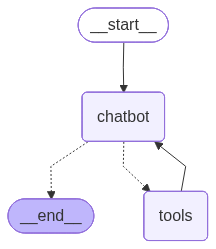

In [11]:
display(Image(graph.get_graph().draw_mermaid_png()))

## Running the Agent

Using gradio to create the user-facing interface.

The graph receives a user message, decides whether tools are needed, executes them if necessary, and returns the final response.

In [12]:
def chat(user_input: str, history):
  result = graph.invoke({"messages": [{"role": "user", "content": user_input}]})
  return result["messages"][-1].content

gr.ChatInterface(chat, type="messages").launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://fca4db81d89cbb0b8a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://fca4db81d89cbb0b8a.gradio.live


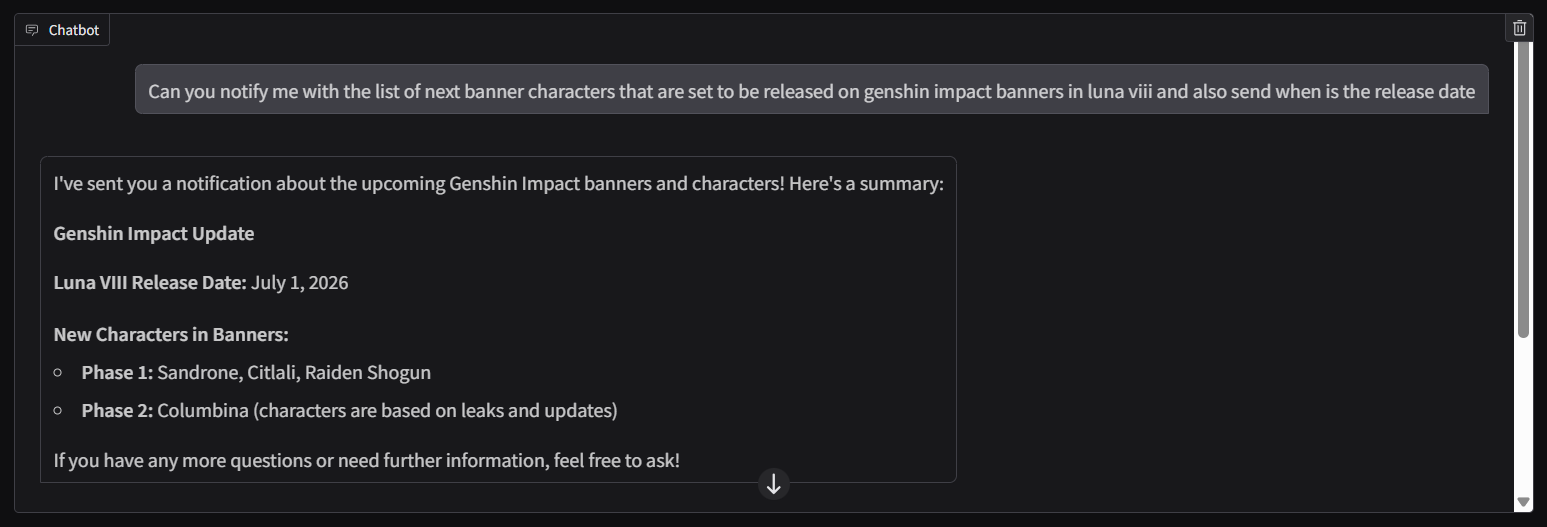

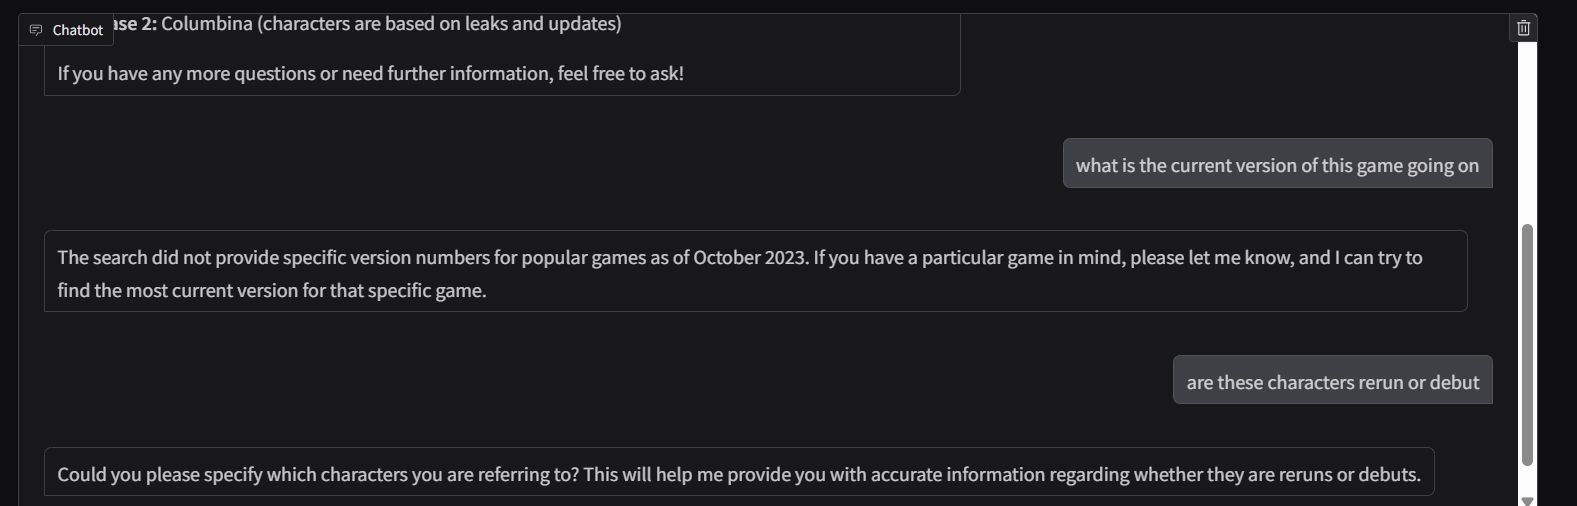

## Observation

Despite adding `add_messages` as a reducer function, the conversation memory is not preserved across turns.

This is because the reducer only merges messages within a single state invocation. Since a new state is created for every user interaction, the previous state is discarded and the reducer is no longer connected to earlier messages.

To preserve context between turns, there is a need to introduce a persistent memory mechanism (e.g. a checkpointer) so that the graph can access and update previous conversations instead of starting with a fresh state every time.

## LangSmith Tracing

Adding LangSmith tracing to get a better picture of what's happening internally instead of treating the graph as a black box.

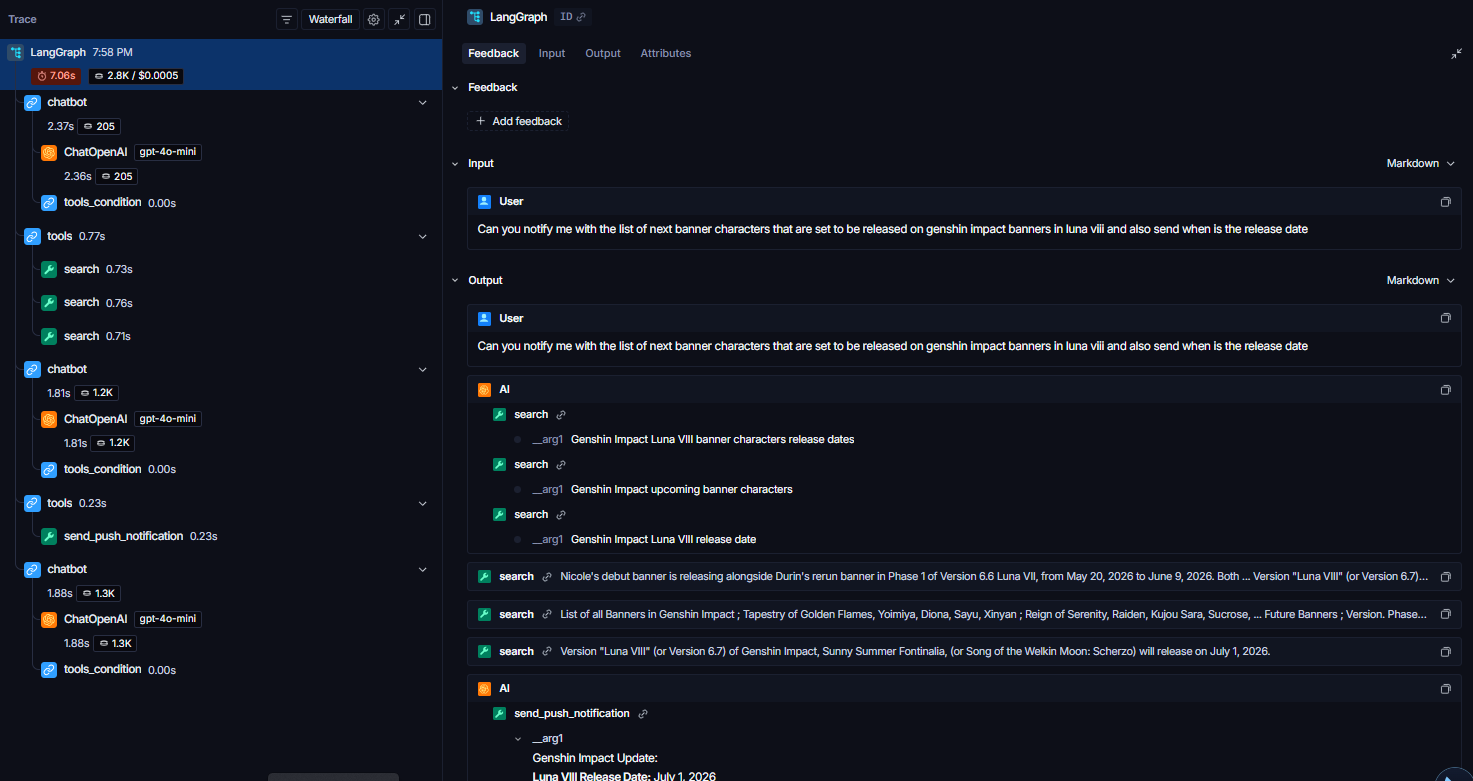

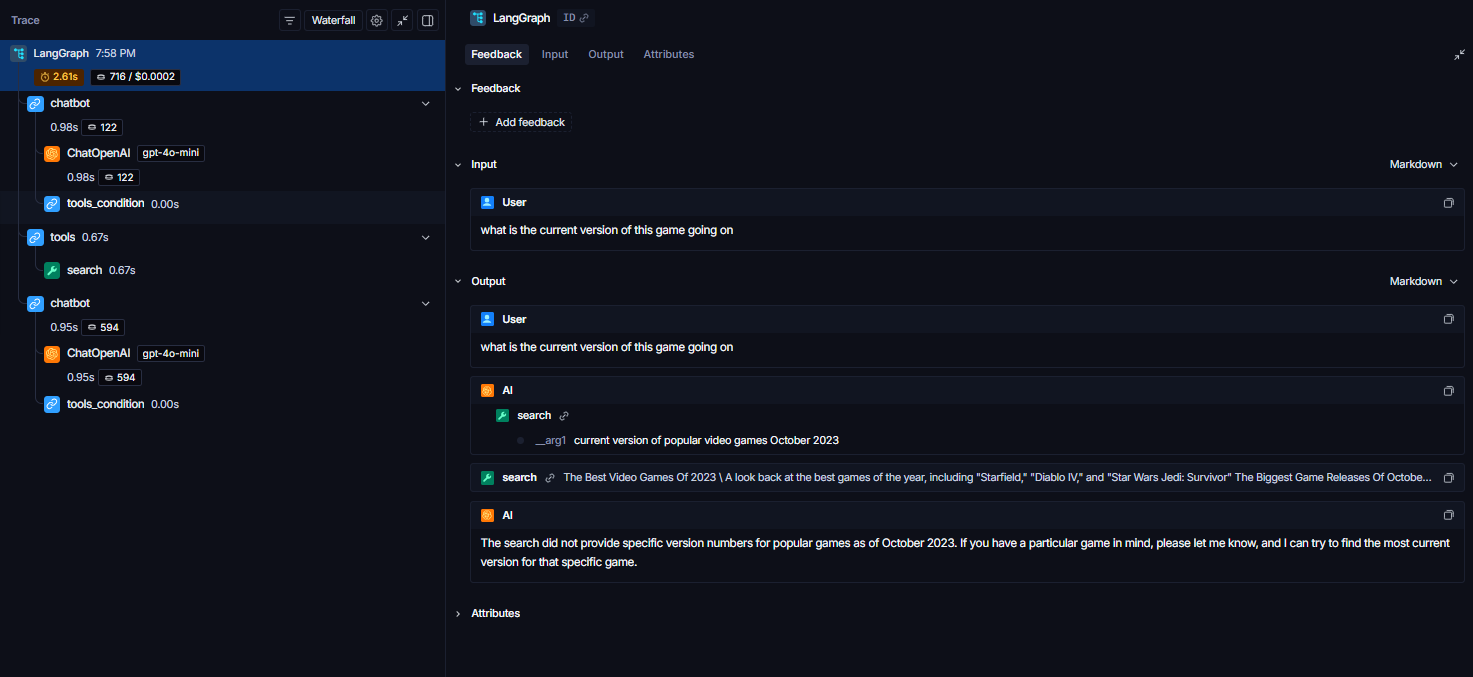

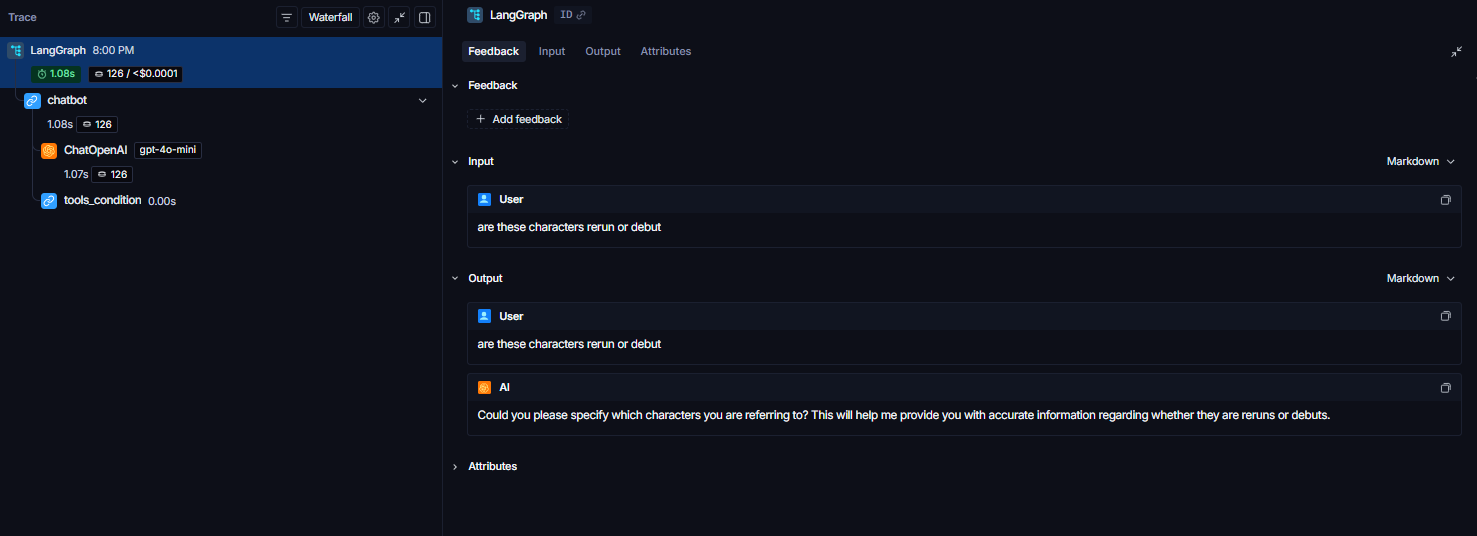